#### Using dynamic time warping to check similarity between training and inference data
- Package: https://dynamictimewarping.github.io/python/
    -   T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.J. Stat. Soft., doi:10.18637/jss.v031.i07.
- DTW aims to find the optimal alignment between two time series by "warping" the time axis of one or both sequences.

 

##### Loading files for training and for inference

In [2]:
import os
from metrics import *
import numpy as np, random
import torchaudio
from torchaudio import transforms
import torch
from dtw import *

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [10]:
#C:\Users\449443\OneDrive - TMNA\ML1\wav2ecg_cavity_orig\dtw_analysis
dir_root = os.path.join("C:\\","Users","449443","OneDrive - TMNA",
                        "ML1","wav2ecg_cavity_orig","dtw_analysis")

#sampling freq for analysis will be lower bc dtw consumes a lot of memory
fs = 200
end_time = 10

In [11]:
#loading all files 
#full_ files contain two rows: ecg + pcg data
[ecg_06, pcg_06], fs_06 = torchaudio.load(os.path.join(dir_root, "HRI_Test_06.wav"))
[ecg_07, pcg_07], fs_07 = torchaudio.load(os.path.join(dir_root, "HRI_Test_07.wav"))
[ecg_08, pcg_08], fs_08 = torchaudio.load(os.path.join(dir_root, "HRI_Test_08.wav"))
[ecg_09, pcg_09], fs_09 = torchaudio.load(os.path.join(dir_root, "HRI_Test_09.wav"))
[_, pcg_raw], fs_raw    = torchaudio.load(os.path.join(dir_root, "Raw_Case 1_EF_HB[_09_].wav"))

In [12]:
#resampling files to fs
resample = transforms.Resample(4000, fs)

ecg_06 = resample(ecg_06)
ecg_07 = resample(ecg_07)
ecg_08 = resample(ecg_08)
ecg_09 = resample(ecg_09)

pcg_06 = resample(pcg_06)
pcg_07 = resample(pcg_07)
pcg_08 = resample(pcg_08)
pcg_09 = resample(pcg_09)
pcg_raw = resample(pcg_raw)

##### DTW analysis

In [42]:
def dtw_analysis(query, template):
    alignment = dtw(query, template, keep_internals=True)

    ## Display the warping curve, i.e. the alignment curve
    alignment.plot(type="threeway")

    ## Align and plot with the Rabiner-Juang type VI-c unsmoothed recursion
    dtw(query, template, keep_internals=True, 
        step_pattern=rabinerJuangStepPattern(6, "c"))\
        .plot(type="twoway",offset=-2)

    # ## See the recursion relation, as formula and diagram
    # print(rabinerJuangStepPattern(6,"c"))
    # rabinerJuangStepPattern(6,"c").plot()

def correlation_analysis(query, template):
    """
    Calculates the Pearson correlation coefficient between two 1D PyTorch tensors.

    Args:
    x: The first 1D PyTorch tensor.
    y: The second 1D PyTorch tensor.

    Returns:
    The Pearson correlation coefficient as a scalar value.
    """

    # Calculate means
    mean_x = torch.mean(query)
    mean_y = torch.mean(template)

    # Calculate centered values
    x_centered = query- mean_x
    y_centered = template - mean_y

    # Calculate covariance
    covariance = torch.sum(x_centered * y_centered) / (len(query) - 1)

    # Calculate standard deviations
    std_x = torch.std(query, unbiased=True)
    std_y = torch.std(template, unbiased=True)

    # Calculate correlation coefficient
    correlation = covariance / (std_x * std_y)

    return correlation

Correlation coefficient betwen 06 and 09: -0.06264124065637589


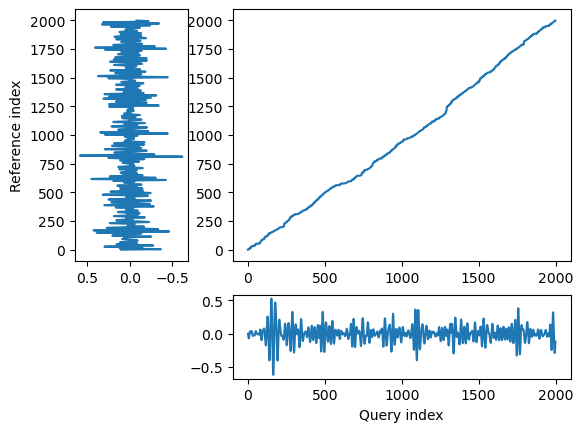

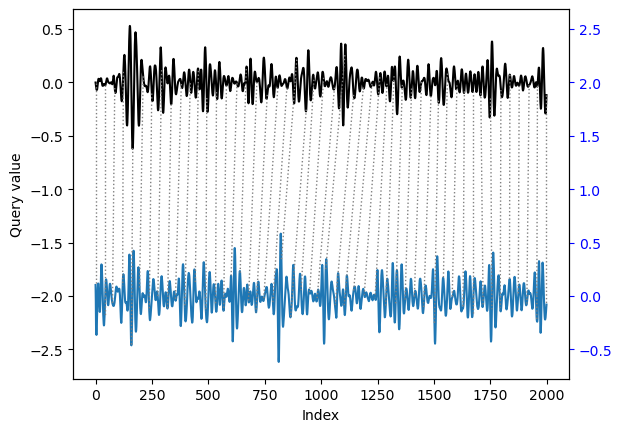

In [43]:
query = pcg_09[0:end_time*fs]
template = pcg_06[0:end_time*fs]

dtw_analysis(query, template)

corr_06_09 = correlation_analysis(query, template)
print(f"Correlation coefficient betwen 06 and 09: {corr_06_09.item()}")

Correlation coefficient betwen 09 and unlabeled data: 0.09802740067243576


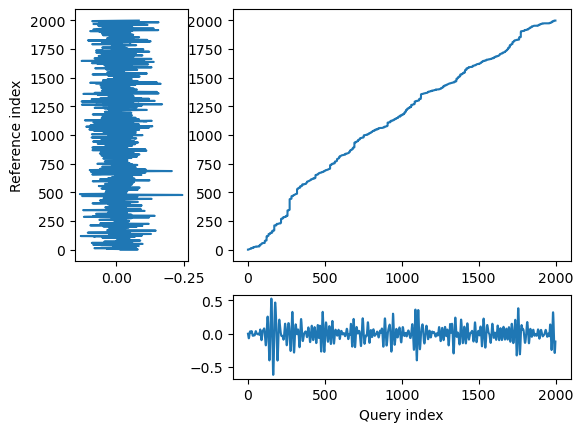

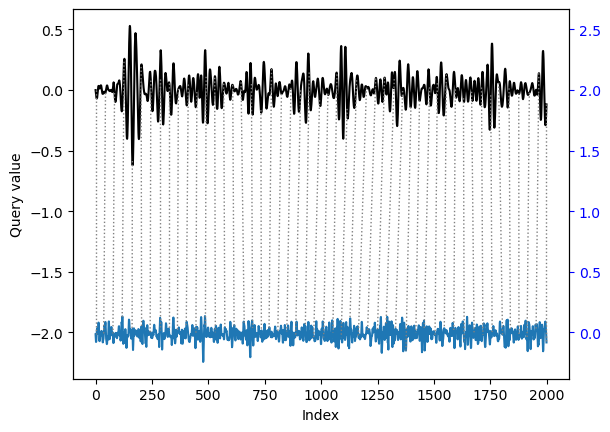

In [45]:
query = pcg_09[0:end_time*fs]
template = pcg_raw[0:end_time*fs]

dtw_analysis(query, template)

corr_09_raw = correlation_analysis(query, template)
print(f"Correlation coefficient betwen 09 and unlabeled data: {corr_09_raw.item()}")

Correlation coefficient betwen 06 and unlabeled data: -0.030597403645515442


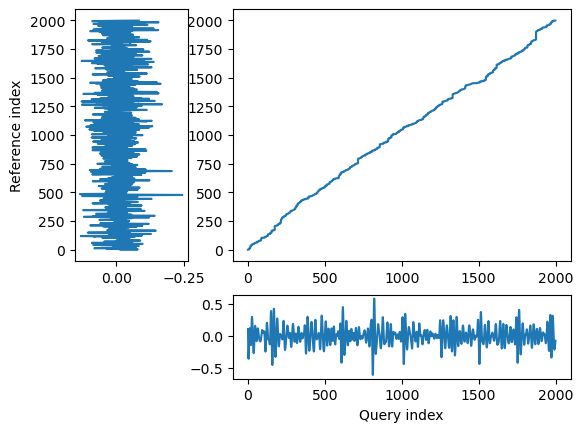

In [41]:
query = pcg_06[0:end_time*fs]
template = pcg_raw[0:end_time*fs]

dtw_analysis(query, template)

corr_06_raw = correlation_analysis(query, template)
print(f"Correlation coefficient betwen 06 and unlabeled data: {corr_06_raw.item()}")

<Axes: >

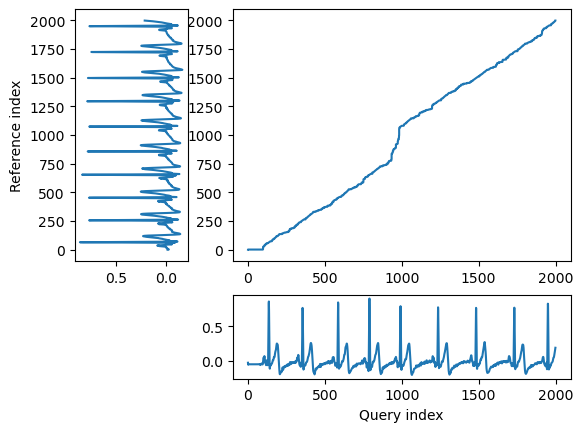

In [15]:
## Find the best match with the canonical recursion formula
# to save memory, only first 20 sec of each plot is used
alignment_06 = dtw(ecg_06[0:end_time*fs], ecg_09[0:end_time*fs], keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment_06.plot(type="threeway")

<Axes: >

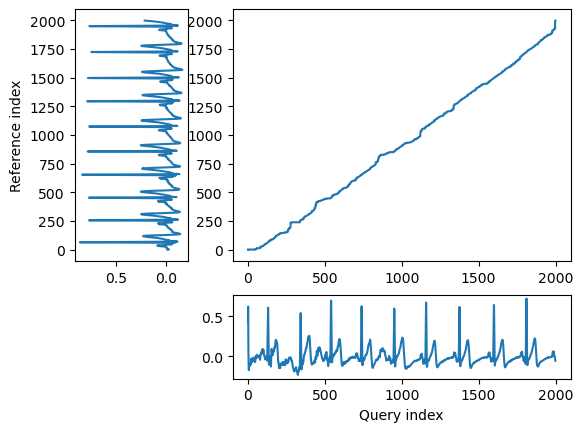

In [16]:
# to save memory, only first 20 sec of each plot is used
alignment_07 = dtw(ecg_07[0:end_time*fs], ecg_09[0:end_time*fs], keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment_07.plot(type="threeway")

<Axes: >

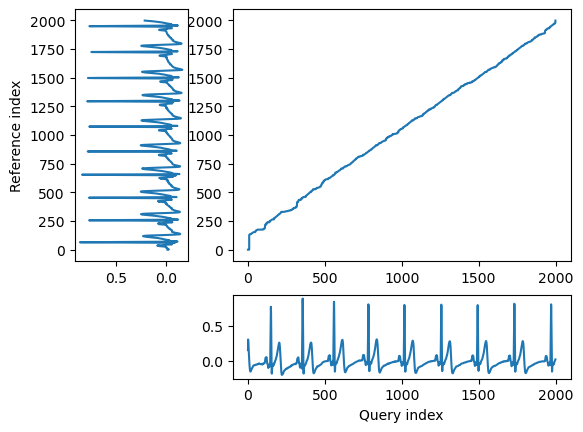

In [17]:
# to save memory, only first 20 sec of each plot is used
alignment_08 = dtw(ecg_08[0:end_time*fs], ecg_09[0:end_time*fs], keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment_08.plot(type="threeway")

<Axes: >

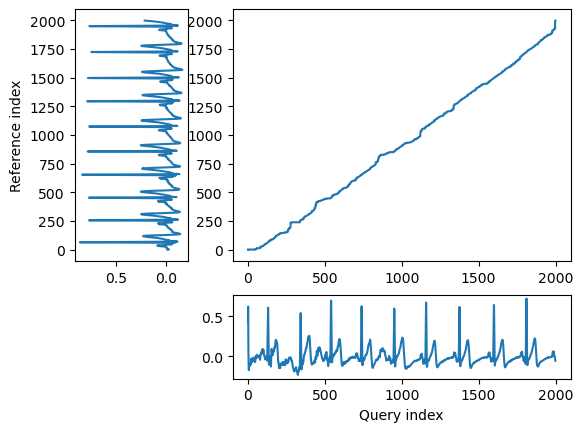

In [18]:
# to save memory, only first 20 sec of each plot is used
alignment_06_07 = dtw(ecg_06[0:end_time*fs], ecg_07[0:end_time*fs], keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment_07.plot(type="threeway")

<Axes: >

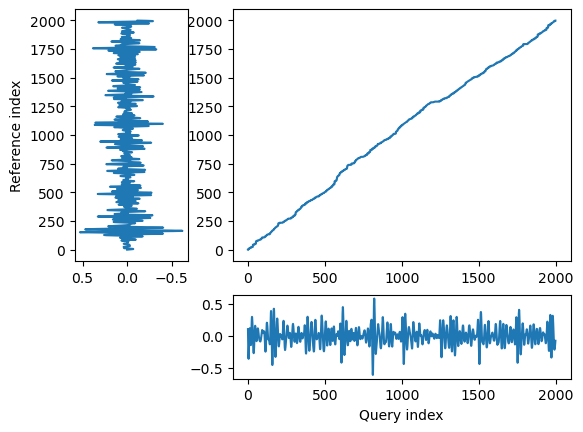

In [19]:
# to save memory, only first 20 sec of each plot is used
alignment_pcg_06 = dtw(pcg_06[0:end_time*fs], pcg_09[0:end_time*fs], keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment_pcg_06.plot(type="threeway")

<Axes: >

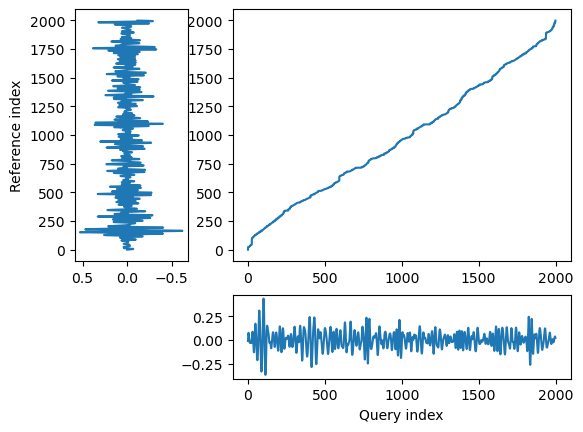

In [20]:
# to save memory, only first 20 sec of each plot is used
alignment_pcg_07 = dtw(pcg_07[0:end_time*fs], pcg_09[0:end_time*fs], keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment_pcg_07.plot(type="threeway")

<Axes: >

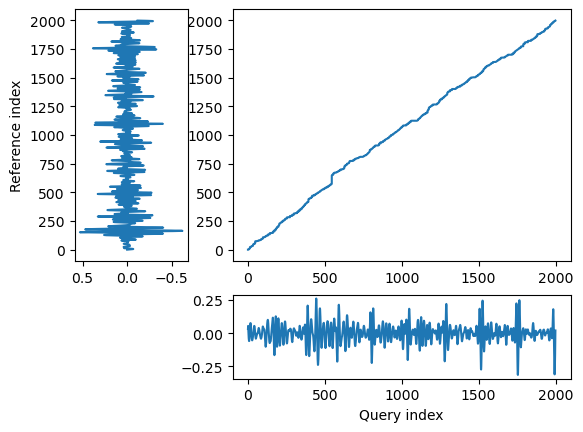

In [21]:
# to save memory, only first 20 sec of each plot is used
alignment_pcg_08 = dtw(pcg_08[0:end_time*fs], pcg_09[0:end_time*fs], keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment_pcg_08.plot(type="threeway")

<Axes: >

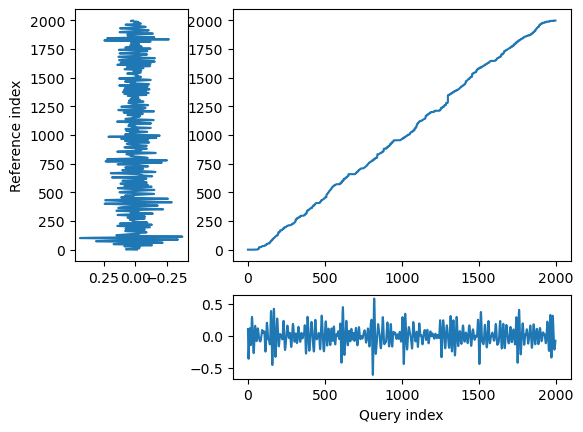

In [22]:
# to save memory, only first 20 sec of each plot is used
alignment_pcg_06_07 = dtw(pcg_06[0:end_time*fs], pcg_07[0:end_time*fs], keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment_pcg_06_07.plot(type="threeway")